In [30]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score

import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
# Project color palette

PROJECT_COLORS = {
    "black": "#000000",
    "dark_gray": "#4A4A4A",
    "green": "#00BF63",
    "primary_blue": "#024DC5",
    "bright_blue": "#0962EF",
    "deep_navy": "#050818",
    "muted_blue": "#3567A1",
    "soft_azure": "#5F8FB3",
    "light_azure": "#AED9F1",
    "light_gray": "#D2D2D2",
    "white": "#FFFFFF",
    "gradient_start": "#0370FF",
    "gradient_end": "#000E59"}

# General palette for non-cluster visuals
MAIN_PALETTE = [
    PROJECT_COLORS["primary_blue"],
    PROJECT_COLORS["green"],
    PROJECT_COLORS["deep_navy"],
    PROJECT_COLORS["bright_blue"],
    PROJECT_COLORS["light_gray"],
    PROJECT_COLORS["muted_blue"],
    PROJECT_COLORS["dark_gray"],
    PROJECT_COLORS["soft_azure"]]

# Stable cluster colors for clearer visual separation
CLUSTER_PALETTE = {
    0: PROJECT_COLORS["soft_azure"],
    1: PROJECT_COLORS["green"],
    2: PROJECT_COLORS["dark_gray"],
    3: PROJECT_COLORS["black"],
    4: PROJECT_COLORS["primary_blue"],
    5: PROJECT_COLORS["deep_navy"],
    -1: PROJECT_COLORS["light_gray"]}

# Ordered list version of the cluster palette
CLUSTER_COLOR_LIST = [
    PROJECT_COLORS["soft_azure"],
    PROJECT_COLORS["green"],
    PROJECT_COLORS["dark_gray"],
    PROJECT_COLORS["black"],
    PROJECT_COLORS["primary_blue"],
    PROJECT_COLORS["deep_navy"]]

# Sequential blue colormap for heatmaps and model-comparison visuals
BLUE_CMAP = LinearSegmentedColormap.from_list(
    "project_blues",
    [
        PROJECT_COLORS["light_azure"],
        PROJECT_COLORS["soft_azure"],
        PROJECT_COLORS["muted_blue"],
        PROJECT_COLORS["primary_blue"],
        PROJECT_COLORS["deep_navy"]])

# Global plot styling
sns.set_theme(style="whitegrid", palette=MAIN_PALETTE)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["figure.titlesize"] = 16
plt.rcParams["axes.facecolor"] = PROJECT_COLORS["white"]
plt.rcParams["figure.facecolor"] = PROJECT_COLORS["white"]
plt.rcParams["savefig.facecolor"] = PROJECT_COLORS["white"]
plt.rcParams["axes.edgecolor"] = PROJECT_COLORS["light_gray"]
plt.rcParams["grid.color"] = PROJECT_COLORS["light_gray"]
plt.rcParams["text.color"] = PROJECT_COLORS["deep_navy"]
plt.rcParams["axes.labelcolor"] = PROJECT_COLORS["deep_navy"]
plt.rcParams["xtick.color"] = PROJECT_COLORS["deep_navy"]
plt.rcParams["ytick.color"] = PROJECT_COLORS["deep_navy"]

In [3]:
DATA_PATH = Path("../1. Data/Customer Data.csv")
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_PATH)
df_model = df.copy()
df_model.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.9007,0.8182,95.4000,0.0000,95.4000,0.0000,0.1667,0.0000,0.0833,0.0000,0,2,"1,000.0000",201.8021,139.5098,0.0000,12
1,C10002,"3,202.4674",0.9091,0.0000,0.0000,0.0000,"6,442.9455",0.0000,0.0000,0.0000,0.2500,4,0,"7,000.0000","4,103.0326","1,072.3402",0.2222,12
2,C10003,"2,495.1489",1.0000,773.1700,773.1700,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0,12,"7,500.0000",622.0667,627.2848,0.0000,12
3,C10004,"1,666.6705",0.6364,"1,499.0000","1,499.0000",0.0000,205.7880,0.0833,0.0833,0.0000,0.0833,1,1,"7,500.0000",0.0000,NaN,0.0000,12
4,C10005,817.7143,1.0000,16.0000,16.0000,0.0000,0.0000,0.0833,0.0833,0.0000,0.0000,0,1,"1,200.0000",678.3348,244.7912,0.0000,12


In [4]:
customer_ids = df_model["CUST_ID"].copy()
numeric_cols = df_model.drop(columns="CUST_ID").columns.tolist()
print(f"Dataset shape: {df_model.shape}")
print(f"Number of numeric features: {len(numeric_cols)}")
df_model.info()

Dataset shape: (8950, 18)
Number of numeric features: 17
<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX       

In [5]:
X = df_model.drop(columns="CUST_ID").copy()
feature_names = X.columns.tolist()
print(f"Baseline feature matrix shape: {X.shape}")
display(X.head())

Baseline feature matrix shape: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.9007,0.8182,95.4000,0.0000,95.4000,0.0000,0.1667,0.0000,0.0833,0.0000,0,2,"1,000.0000",201.8021,139.5098,0.0000,12
1,"3,202.4674",0.9091,0.0000,0.0000,0.0000,"6,442.9455",0.0000,0.0000,0.0000,0.2500,4,0,"7,000.0000","4,103.0326","1,072.3402",0.2222,12
2,"2,495.1489",1.0000,773.1700,773.1700,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0,12,"7,500.0000",622.0667,627.2848,0.0000,12
3,"1,666.6705",0.6364,"1,499.0000","1,499.0000",0.0000,205.7880,0.0833,0.0833,0.0000,0.0833,1,1,"7,500.0000",0.0000,NaN,0.0000,12
4,817.7143,1.0000,16.0000,16.0000,0.0000,0.0000,0.0833,0.0833,0.0000,0.0000,0,1,"1,200.0000",678.3348,244.7912,0.0000,12


In [7]:
baseline_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())])

In [8]:
X_baseline = baseline_preprocessor.fit_transform(X)
X_baseline_df = pd.DataFrame(X_baseline, columns=feature_names, index=X.index)
print(f"Baseline transformed matrix shape: {X_baseline_df.shape}")
display(X_baseline_df.head())

Baseline transformed matrix shape: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.4323,-1.6364,-0.2484,-0.0658,0.0137,0.0000,-0.4000,-0.2778,-0.1111,0.0000,0.0000,-0.3125,-0.4082,-0.4316,-0.2797,0.0000,0.0000
1,1.2094,-0.8182,-0.3375,-0.0658,-0.1899,5.7845,-0.6000,-0.2778,-0.2222,1.1250,1.0000,-0.4375,0.8163,2.1386,1.2301,1.5556,0.0000
2,0.8421,0.0000,0.3848,1.2732,-0.1899,0.0000,0.6000,3.0556,-0.2222,0.0000,0.0000,0.3125,0.9184,-0.1547,0.5097,0.0000,0.0000
3,0.4119,-3.2727,1.0628,2.5303,-0.1899,0.1848,-0.5000,0.0000,-0.2222,0.3750,0.2500,-0.3750,0.9184,-0.5645,0.0000,0.0000,0.0000
4,-0.0289,0.0000,-0.3225,-0.0381,-0.1899,0.0000,-0.5000,0.0000,-0.2222,0.0000,0.0000,-0.3750,-0.3673,-0.1176,-0.1093,0.0000,0.0000


In [9]:
X_baseline_df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,"8,950.0000",0.3588,1.0808,-0.4535,-0.3869,0.0000,0.6131,9.4346
BALANCE_FREQUENCY,"8,950.0000",-1.1046,2.1321,-9.0000,-1.0000,0.0000,0.0000,0.0000
PURCHASES,"8,950.0000",0.5997,1.9959,-0.3375,-0.3005,0.0000,0.6995,45.4727
ONEOFF_PURCHASES,"8,950.0000",0.9602,2.8747,-0.0658,-0.0658,0.0000,0.9342,70.5281
INSTALLMENTS_PURCHASES,"8,950.0000",0.6872,1.9297,-0.1899,-0.1899,0.0000,0.8101,47.8216
CASH_ADVANCE,"8,950.0000",0.8788,1.8829,0.0000,0.0000,0.0000,1.0000,42.3203
PURCHASES_FREQUENCY,"8,950.0000",-0.0116,0.4816,-0.6000,-0.5000,0.0000,0.5000,0.6000
ONEOFF_PURCHASES_FREQUENCY,"8,950.0000",0.3971,0.9945,-0.2778,-0.2778,0.0000,0.7222,3.0556
PURCHASES_INSTALLMENTS_FREQUENCY,"8,950.0000",0.2637,0.5299,-0.2222,-0.2222,0.0000,0.7778,1.1111
CASH_ADVANCE_FREQUENCY,"8,950.0000",0.6081,0.9005,0.0000,0.0000,0.0000,1.0000,6.7500


In [19]:
# Create a function to fit one clustering model and calculate evaluation metrics
def evaluate_clustering_solution(X_input, model_name, n_clusters):
    """
    Fit a clustering model, generate cluster labels,
    and calculate internal clustering metrics plus cluster-size diagnostics.
    """    
    # Select the clustering model based on the requested name
    if model_name == "KMeans":
        model = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
        labels = model.fit_predict(X_input)
    
    elif model_name == "Agglomerative":
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
        labels = model.fit_predict(X_input)
    
    elif model_name == "GaussianMixture":
        model = GaussianMixture(n_components=n_clusters, covariance_type="full", random_state=42)
        labels = model.fit_predict(X_input)
    
    else:
        raise ValueError(f"Unknown model name: {model_name}")
    
    # Count how many points belong to each cluster
    cluster_sizes = pd.Series(labels).value_counts(normalize=True).sort_index()
    
    # Calculate internal evaluation metrics
    silhouette = silhouette_score(X_input, labels)
    davies_bouldin = davies_bouldin_score(X_input, labels)
    calinski_harabasz = calinski_harabasz_score(X_input, labels)
    
    # Calculate simple cluster-balance diagnostics
    smallest_cluster_pct = cluster_sizes.min() * 100
    largest_cluster_pct = cluster_sizes.max() * 100
    
    # Return all results in dictionary form
    return {
        "model": model_name,
        "n_clusters": n_clusters,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
        "calinski_harabasz_score": calinski_harabasz,
        "smallest_cluster_pct": smallest_cluster_pct,
        "largest_cluster_pct": largest_cluster_pct,
        "labels": labels}

In [ ]:
model_names = ["KMeans", "Agglomerative", "GaussianMixture"]
cluster_range = range(2, 7)
baseline_results = []
baseline_labels_store = {}
for model_name in model_names:
    for n_clusters in cluster_range:
        result = evaluate_clustering_solution(
            X_input=X_baseline_df,
            model_name=model_name,
            n_clusters=n_clusters)
        baseline_labels_store[(model_name, n_clusters)] = result["labels"]
        result_row = result.copy()
        result_row.pop("labels")
        baseline_results.append(result_row)
baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df

,model,n_clusters,silhouette_score,davies_bouldin_score,calinski_harabasz_score,smallest_cluster_pct,largest_cluster_pct
0,KMeans,2,0.6631,1.4793,"1,684.5129",4.1564,95.8436
1,KMeans,3,0.5601,1.0886,"1,791.4739",0.6704,93.8994
2,KMeans,4,0.3068,1.2997,"1,725.6358",0.4246,79.7877
3,KMeans,5,0.3108,1.1606,"1,778.9378",0.2458,75.2067
4,KMeans,6,0.2697,1.1576,"1,840.5125",0.2570,61.1508
5,Agglomerative,2,0.7124,0.7665,"1,317.3840",1.1173,98.8827
6,Agglomerative,3,0.7168,0.7028,"1,386.7182",0.2123,98.6704
7,Agglomerative,4,0.2738,1.2136,"1,440.5061",0.2123,82.9832
8,Agglomerative,5,0.1971,1.3109,"1,477.9873",0.2123,55.6648
9,Agglomerative,6,0.1828,1.3057,"1,467.3560",0.2123,45.0168


In [12]:
baseline_results_sorted = baseline_results_df.sort_values(
    by=["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"],
    ascending=[False, True, False]).reset_index(drop=True)
baseline_results_sorted

,model,n_clusters,silhouette_score,davies_bouldin_score,calinski_harabasz_score,smallest_cluster_pct,largest_cluster_pct
0,Agglomerative,3,0.7168,0.7028,"1,386.7182",0.2123,98.6704
1,Agglomerative,2,0.7124,0.7665,"1,317.3840",1.1173,98.8827
2,KMeans,2,0.6631,1.4793,"1,684.5129",4.1564,95.8436
3,KMeans,3,0.5601,1.0886,"1,791.4739",0.6704,93.8994
4,KMeans,5,0.3108,1.1606,"1,778.9378",0.2458,75.2067
5,KMeans,4,0.3068,1.2997,"1,725.6358",0.4246,79.7877
6,Agglomerative,4,0.2738,1.2136,"1,440.5061",0.2123,82.9832
7,KMeans,6,0.2697,1.1576,"1,840.5125",0.2570,61.1508
8,Agglomerative,5,0.1971,1.3109,"1,477.9873",0.2123,55.6648
9,Agglomerative,6,0.1828,1.3057,"1,467.3560",0.2123,45.0168


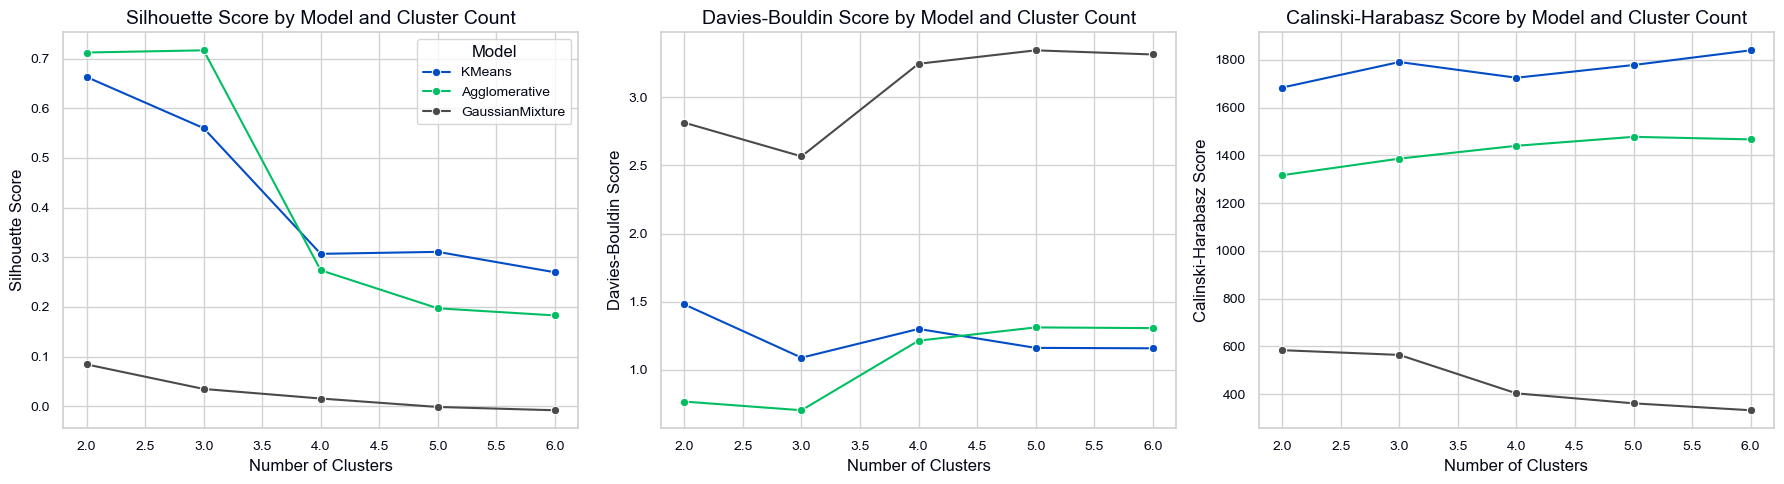

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
sns.lineplot(
    data=baseline_results_df,
    x="n_clusters",
    y="silhouette_score",
    hue="model",
    marker="o",
    palette={
        "KMeans": PROJECT_COLORS["primary_blue"],
        "Agglomerative": PROJECT_COLORS["green"],
        "GaussianMixture": PROJECT_COLORS["dark_gray"]},
    ax=axes[0])
axes[0].set_title("Silhouette Score by Model and Cluster Count")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Silhouette Score")

sns.lineplot(
    data=baseline_results_df,
    x="n_clusters",
    y="davies_bouldin_score",
    hue="model",
    marker="o",
    palette={
        "KMeans": PROJECT_COLORS["primary_blue"],
        "Agglomerative": PROJECT_COLORS["green"],
        "GaussianMixture": PROJECT_COLORS["dark_gray"]},
    ax=axes[1])
axes[1].set_title("Davies-Bouldin Score by Model and Cluster Count")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Davies-Bouldin Score")

sns.lineplot(
    data=baseline_results_df,
    x="n_clusters",
    y="calinski_harabasz_score",
    hue="model",
    marker="o",
    palette={
        "KMeans": PROJECT_COLORS["primary_blue"],
        "Agglomerative": PROJECT_COLORS["green"],
        "GaussianMixture": PROJECT_COLORS["dark_gray"]},
    ax=axes[2])
axes[2].set_title("Calinski-Harabasz Score by Model and Cluster Count")
axes[2].set_xlabel("Number of Clusters")
axes[2].set_ylabel("Calinski-Harabasz Score")

axes[0].legend(title="Model")
axes[1].legend_.remove()
axes[2].legend_.remove()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "01_baseline_model_comparison_metrics.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

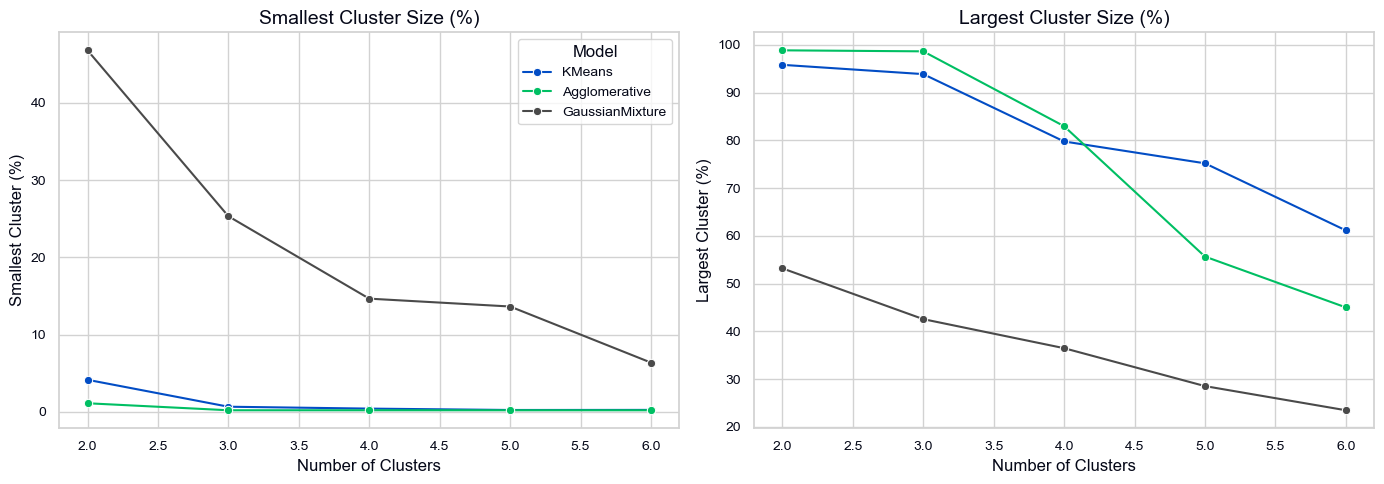

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.lineplot(
    data=baseline_results_df,
    x="n_clusters",
    y="smallest_cluster_pct",
    hue="model",
    marker="o",
    palette={
        "KMeans": PROJECT_COLORS["primary_blue"],
        "Agglomerative": PROJECT_COLORS["green"],
        "GaussianMixture": PROJECT_COLORS["dark_gray"]},
    ax=axes[0])
axes[0].set_title("Smallest Cluster Size (%)")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Smallest Cluster (%)")

sns.lineplot(
    data=baseline_results_df,
    x="n_clusters",
    y="largest_cluster_pct",
    hue="model",
    marker="o",
    palette={
        "KMeans": PROJECT_COLORS["primary_blue"],
        "Agglomerative": PROJECT_COLORS["green"],
        "GaussianMixture": PROJECT_COLORS["dark_gray"]},
    ax=axes[1])
axes[1].set_title("Largest Cluster Size (%)")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Largest Cluster (%)")

axes[0].legend(title="Model")
axes[1].legend_.remove()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "02_baseline_cluster_balance_diagnostics.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [17]:
# Create a helper function to generate cluster labels for a selected model and cluster count
def get_cluster_labels(X_input, model_name, n_clusters):
    """
    Fit the requested clustering model and return cluster labels.
    """
    if model_name == "KMeans":
        model = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
        labels = model.fit_predict(X_input)
    elif model_name == "Agglomerative":
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
        labels = model.fit_predict(X_input)
    elif model_name == "GaussianMixture":
        model = GaussianMixture(n_components=n_clusters, covariance_type="full", random_state=42)
        labels = model.fit_predict(X_input)    
    else:
        raise ValueError(f"Unknown model name: {model_name}")    
    return labels

In [20]:
# Create a function to draw silhouette plots for k = 2, 3, 4 in one row
def plot_silhouette_grid(X_input, model_name, k_values, file_name):
    """
    Draw silhouette plots for multiple k values in a single figure.
    One subplot per k.
    """
    # Create one row of subplots
    fig, axes = plt.subplots(nrows=1, ncols=len(k_values), figsize=(18, 5))
    # Make sure axes is always iterable
    if len(k_values) == 1:
        axes = [axes]    
    # Loop through each requested k value
    for ax, k in zip(axes, k_values):
        # Get cluster labels for the current solution
        labels = get_cluster_labels(X_input, model_name, k)        
        # Compute silhouette metrics
        avg_silhouette = silhouette_score(X_input, labels)
        sample_silhouette_values = silhouette_samples(X_input, labels)        
        # Set up vertical positioning
        y_lower = 10        
        # Plot each cluster block
        for cluster_id in sorted(np.unique(labels)):
            cluster_silhouette_values = sample_silhouette_values[labels == cluster_id]
            cluster_silhouette_values.sort()            
            cluster_size = cluster_silhouette_values.shape[0]
            y_upper = y_lower + cluster_size            
            color = CLUSTER_PALETTE.get(cluster_id, PROJECT_COLORS["light_gray"])            
            ax.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                cluster_silhouette_values,
                facecolor=color,
                edgecolor=PROJECT_COLORS["deep_navy"],
                alpha=0.85)            
            # Add the cluster label in the middle of the block
            ax.text(-0.05, y_lower + 0.5 * cluster_size, str(cluster_id), fontsize=9)            
            # Move to the next cluster block
            y_lower = y_upper + 10        
        # Add the average silhouette reference line
        ax.axvline(
            x=avg_silhouette,
            color=PROJECT_COLORS["green"],
            linestyle="--",
            linewidth=2)        
        # Format the subplot
        ax.set_title(f"{model_name} (k={k})\nAvg silhouette = {avg_silhouette:.3f}")
        ax.set_xlabel("Silhouette Coefficient")
        ax.set_ylabel("Cluster Label")
        ax.set_yticks([])
        ax.set_xlim([-0.25, 1.0])    
    fig.suptitle(f"{model_name} Silhouette Analysis", fontsize=16)
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / file_name,
        dpi=300,
        bbox_inches="tight")
    plt.show()

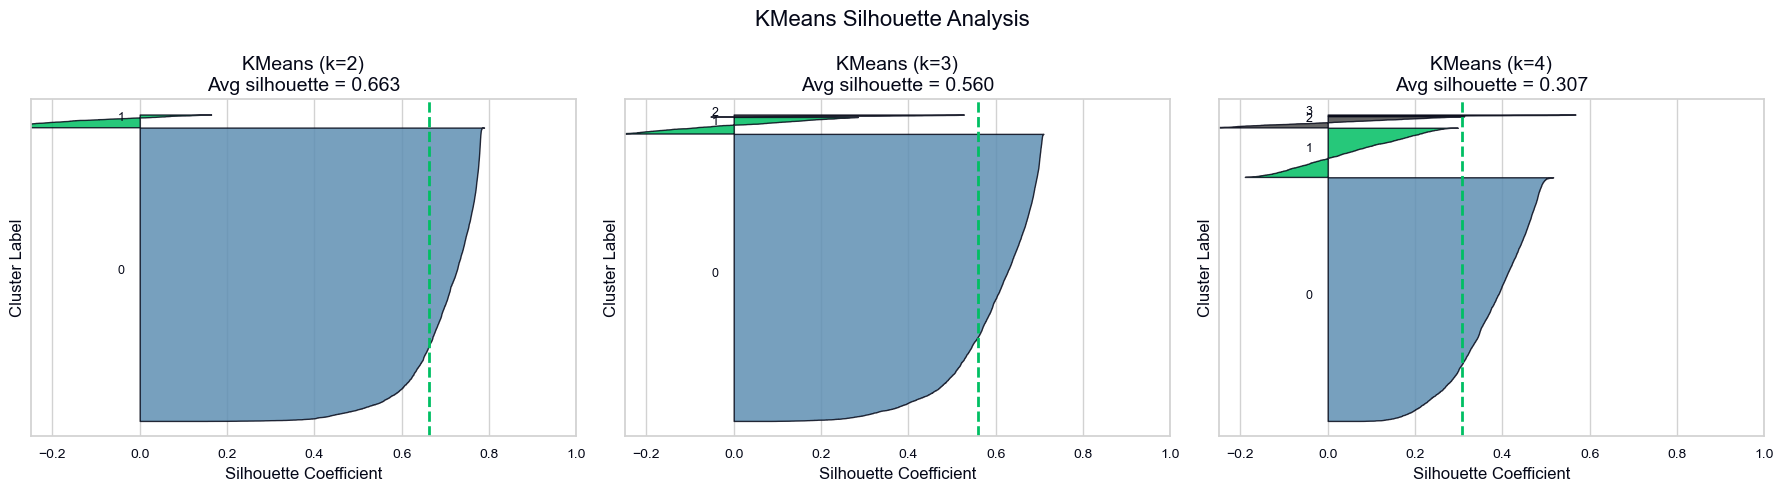

In [27]:
plot_silhouette_grid(X_baseline_df, "KMeans", [2, 3, 4], file_name="03_kmeans_silhouette_grid_k_2_3_4.png")

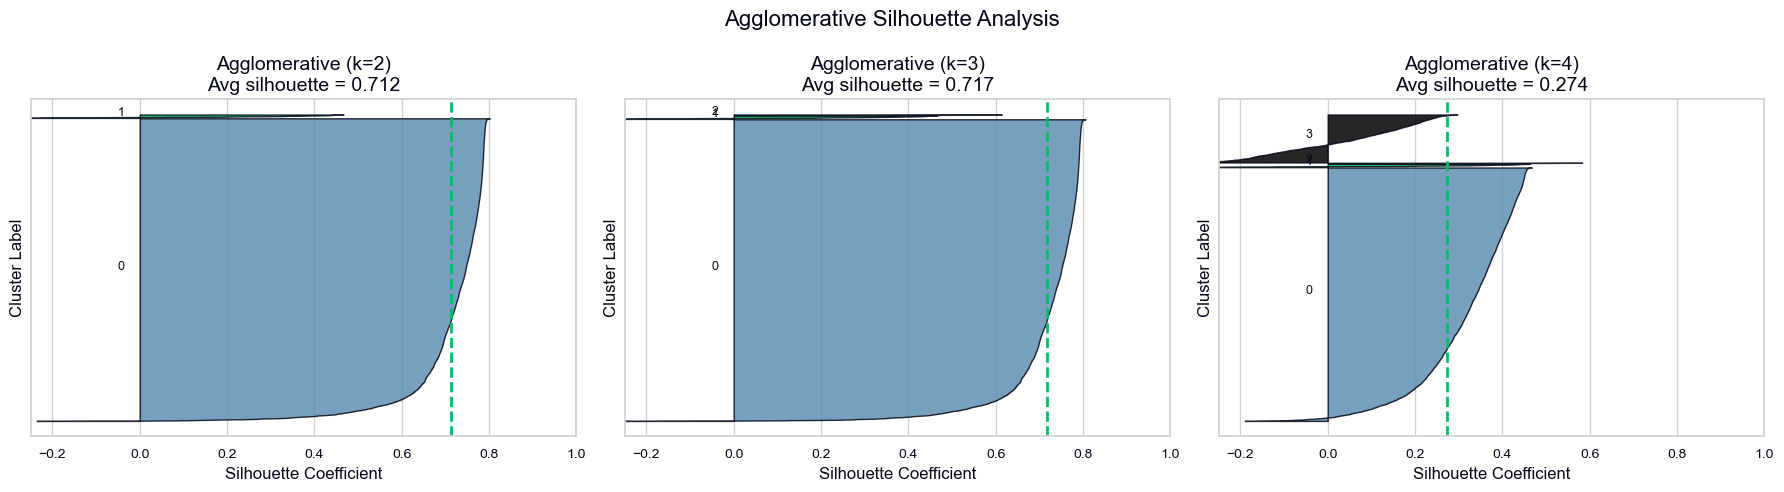

In [28]:
plot_silhouette_grid(X_baseline_df, "Agglomerative", [2, 3, 4], "04_agglomerative_silhouette_grid_k_2_3_4.png")

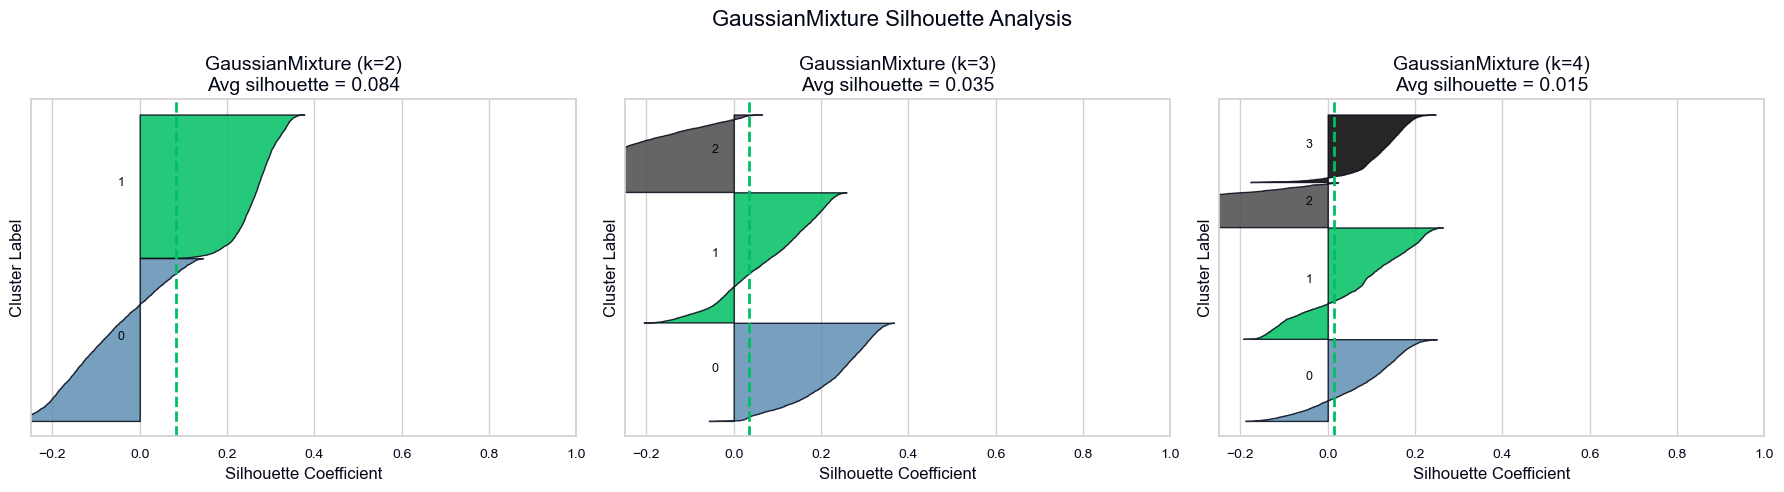

In [29]:
plot_silhouette_grid(X_baseline_df, "GaussianMixture", [2, 3, 4], "05_gmm_silhouette_grid_k_2_3_4.png")

In [31]:
skewed_features = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS"]
remaining_features = [col for col in feature_names if col not in skewed_features]
enhanced_feature_order = skewed_features + remaining_features
print(f"Skewed features: {len(skewed_features)}")
print(f"Remaining features: {len(remaining_features)}")
skewed_features

Skewed features: 8
Remaining features: 9


['BALANCE',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS']

In [32]:
enhanced_preprocessor = Pipeline([
    (
        "column_transform",
        ColumnTransformer(
            transformers=[
                (
                    "skewed_block",
                    Pipeline([
                        ("imputer", SimpleImputer(strategy="median")),
                        ("power", PowerTransformer(method="yeo-johnson", standardize=False))
                    ]),
                    skewed_features
                ),
                (
                    "remaining_block",
                    Pipeline([
                        ("imputer", SimpleImputer(strategy="median"))
                    ]),
                    remaining_features
                )
            ],
            remainder="drop",
            verbose_feature_names_out=False
        )
    ),
    ("scaler", RobustScaler())
])


In [33]:
X_enhanced = enhanced_preprocessor.fit_transform(X)
X_enhanced_df = pd.DataFrame(X_enhanced, columns=enhanced_feature_order, index=X.index)
print(f"Enhanced transformed matrix shape: {X_enhanced_df.shape}")
X_enhanced_df.head()

Enhanced transformed matrix shape: (8950, 17)


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PRC_FULL_PAYMENT,TENURE
0,-0.9056,-0.3874,-0.6217,0.0113,-0.0000,-0.7574,-0.7804,-0.5410,-1.6364,-0.4000,-0.2778,-0.1111,0.0000,0.0000,-0.3125,0.0000,0.0000
1,0.5866,-1.2204,-0.6217,-0.7264,1.1701,0.6161,1.1453,0.7889,-0.8182,-0.6000,-0.2778,-0.2222,1.1250,1.0000,-0.4375,1.5556,0.0000
2,0.4619,0.2644,0.4157,-0.7264,-0.0000,0.6675,-0.1930,0.4518,0.0000,0.6000,3.0556,-0.2222,0.0000,0.0000,0.3125,0.0000,0.0000
3,0.2729,0.5238,0.4982,-0.7264,0.8110,0.6675,-2.3064,0.0000,-3.2727,-0.5000,0.0000,-0.2222,0.3750,0.2500,-0.3750,0.0000,0.0000
4,-0.0259,-0.7806,-0.1293,-0.7264,-0.0000,-0.6349,-0.1420,-0.1615,0.0000,-0.5000,0.0000,-0.2222,0.0000,0.0000,-0.3750,0.0000,0.0000


In [34]:
X_enhanced_df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,"8,950.0000",-0.0988,0.6516,-1.4804,-0.6311,0.0000,0.3689,1.6808
PURCHASES,"8,950.0000",-0.1178,0.7326,-1.2204,-0.5975,0.0000,0.4025,2.4895
ONEOFF_PURCHASES,"8,950.0000",-0.1193,0.5022,-0.6217,-0.6217,0.0000,0.3783,0.8645
INSTALLMENTS_PURCHASES,"8,950.0000",-0.1814,0.5022,-0.7264,-0.7264,0.0000,0.2736,0.9293
CASH_ADVANCE,"8,950.0000",0.4714,0.4991,-0.0000,0.0000,-0.0000,1.0000,1.3348
CREDIT_LIMIT,"8,950.0000",0.0758,0.5846,-2.5975,-0.4390,0.0000,0.5610,1.7429
PAYMENTS,"8,950.0000",0.0546,0.8487,-2.3064,-0.4622,0.0000,0.5378,3.9316
MINIMUM_PAYMENTS,"8,950.0000",0.0884,0.7636,-4.3937,-0.4031,0.0000,0.5969,3.1706
BALANCE_FREQUENCY,"8,950.0000",-1.1046,2.1321,-9.0000,-1.0000,0.0000,0.0000,0.0000
PURCHASES_FREQUENCY,"8,950.0000",-0.0116,0.4816,-0.6000,-0.5000,0.0000,0.5000,0.6000


In [35]:
model_names = ["KMeans", "Agglomerative", "GaussianMixture"]
cluster_range = range(2, 7)
enhanced_results = []
enhanced_labels_store = {}
for model_name in model_names:
    for n_clusters in cluster_range:
        result = evaluate_clustering_solution(X_enhanced_df, model_name, n_clusters)
        enhanced_labels_store[(model_name, n_clusters)] = result["labels"]
        result_row = result.copy()
        result_row.pop("labels")
        enhanced_results.append(result_row)
enhanced_results_df = pd.DataFrame(enhanced_results)
enhanced_results_df

,model,n_clusters,silhouette_score,davies_bouldin_score,calinski_harabasz_score,smallest_cluster_pct,largest_cluster_pct
0,KMeans,2,0.3114,1.6928,"2,344.8582",27.9888,72.0112
1,KMeans,3,0.3488,1.1555,"2,551.0433",14.4022,71.0838
2,KMeans,4,0.3007,1.2545,"2,501.9915",13.0726,59.1061
3,KMeans,5,0.2766,1.2166,"2,457.6165",10.1341,49.6536
4,KMeans,6,0.3023,1.1326,"2,402.8652",6.3464,47.8436
5,Agglomerative,2,0.2813,1.7632,"2,139.2606",29.1844,70.8156
6,Agglomerative,3,0.3150,1.2098,"2,245.8292",14.1899,70.8156
7,Agglomerative,4,0.2034,1.5220,"2,132.2131",14.1899,36.9497
8,Agglomerative,5,0.1970,1.4564,"2,014.5226",4.5922,36.9497
9,Agglomerative,6,0.2011,1.3476,"1,940.5774",1.1508,35.7989


In [36]:
enhanced_results_sorted = enhanced_results_df.sort_values(
    by=["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"],
    ascending=[False, True, False]
).reset_index(drop=True)
enhanced_results_sorted

,model,n_clusters,silhouette_score,davies_bouldin_score,calinski_harabasz_score,smallest_cluster_pct,largest_cluster_pct
0,KMeans,3,0.3488,1.1555,"2,551.0433",14.4022,71.0838
1,Agglomerative,3,0.3150,1.2098,"2,245.8292",14.1899,70.8156
2,KMeans,2,0.3114,1.6928,"2,344.8582",27.9888,72.0112
3,KMeans,6,0.3023,1.1326,"2,402.8652",6.3464,47.8436
4,KMeans,4,0.3007,1.2545,"2,501.9915",13.0726,59.1061
5,Agglomerative,2,0.2813,1.7632,"2,139.2606",29.1844,70.8156
6,KMeans,5,0.2766,1.2166,"2,457.6165",10.1341,49.6536
7,Agglomerative,4,0.2034,1.5220,"2,132.2131",14.1899,36.9497
8,Agglomerative,6,0.2011,1.3476,"1,940.5774",1.1508,35.7989
9,Agglomerative,5,0.1970,1.4564,"2,014.5226",4.5922,36.9497


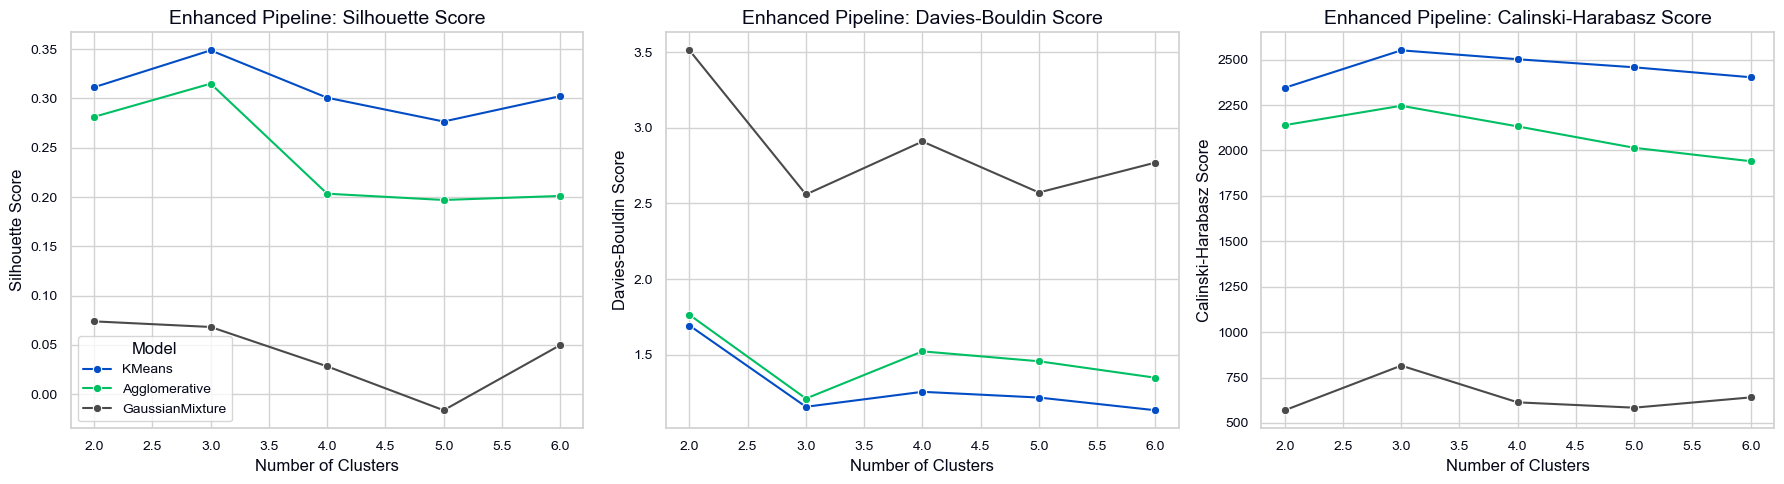

In [37]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
sns.lineplot(
    data=enhanced_results_df,
    x="n_clusters",
    y="silhouette_score",
    hue="model",
    marker="o",
    palette={
        "KMeans": PROJECT_COLORS["primary_blue"],
        "Agglomerative": PROJECT_COLORS["green"],
        "GaussianMixture": PROJECT_COLORS["dark_gray"]},
    ax=axes[0])
axes[0].set_title("Enhanced Pipeline: Silhouette Score")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Silhouette Score")

sns.lineplot(
    data=enhanced_results_df,
    x="n_clusters",
    y="davies_bouldin_score",
    hue="model",
    marker="o",
    palette={
        "KMeans": PROJECT_COLORS["primary_blue"],
        "Agglomerative": PROJECT_COLORS["green"],
        "GaussianMixture": PROJECT_COLORS["dark_gray"]},
    ax=axes[1])
axes[1].set_title("Enhanced Pipeline: Davies-Bouldin Score")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Davies-Bouldin Score")

sns.lineplot(
    data=enhanced_results_df,
    x="n_clusters",
    y="calinski_harabasz_score",
    hue="model",
    marker="o",
    palette={
        "KMeans": PROJECT_COLORS["primary_blue"],
        "Agglomerative": PROJECT_COLORS["green"],
        "GaussianMixture": PROJECT_COLORS["dark_gray"]},
    ax=axes[2])
axes[2].set_title("Enhanced Pipeline: Calinski-Harabasz Score")
axes[2].set_xlabel("Number of Clusters")
axes[2].set_ylabel("Calinski-Harabasz Score")

axes[0].legend(title="Model")
axes[1].legend_.remove()
axes[2].legend_.remove()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "06_enhanced_model_comparison_metrics.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

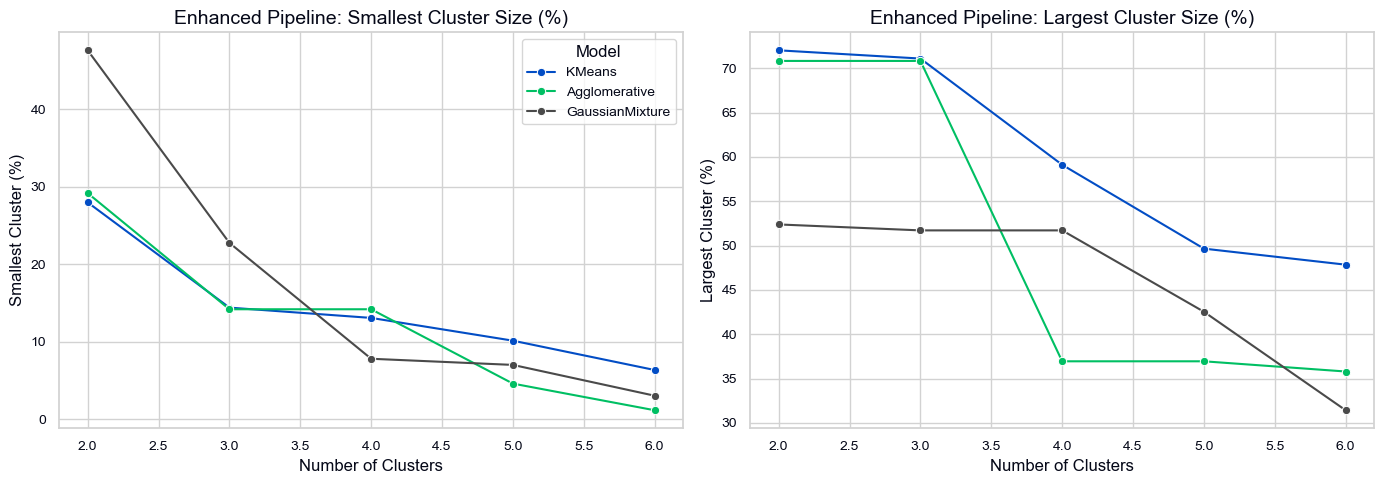

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

sns.lineplot(
    data=enhanced_results_df,
    x="n_clusters",
    y="smallest_cluster_pct",
    hue="model",
    marker="o",
    palette={
        "KMeans": PROJECT_COLORS["primary_blue"],
        "Agglomerative": PROJECT_COLORS["green"],
        "GaussianMixture": PROJECT_COLORS["dark_gray"]},
    ax=axes[0])
axes[0].set_title("Enhanced Pipeline: Smallest Cluster Size (%)")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Smallest Cluster (%)")

sns.lineplot(
    data=enhanced_results_df,
    x="n_clusters",
    y="largest_cluster_pct",
    hue="model",
    marker="o",
    palette={
        "KMeans": PROJECT_COLORS["primary_blue"],
        "Agglomerative": PROJECT_COLORS["green"],
        "GaussianMixture": PROJECT_COLORS["dark_gray"]},
    ax=axes[1])
axes[1].set_title("Enhanced Pipeline: Largest Cluster Size (%)")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Largest Cluster (%)")

axes[0].legend(title="Model")
axes[1].legend_.remove()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "07_enhanced_cluster_balance_diagnostics.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

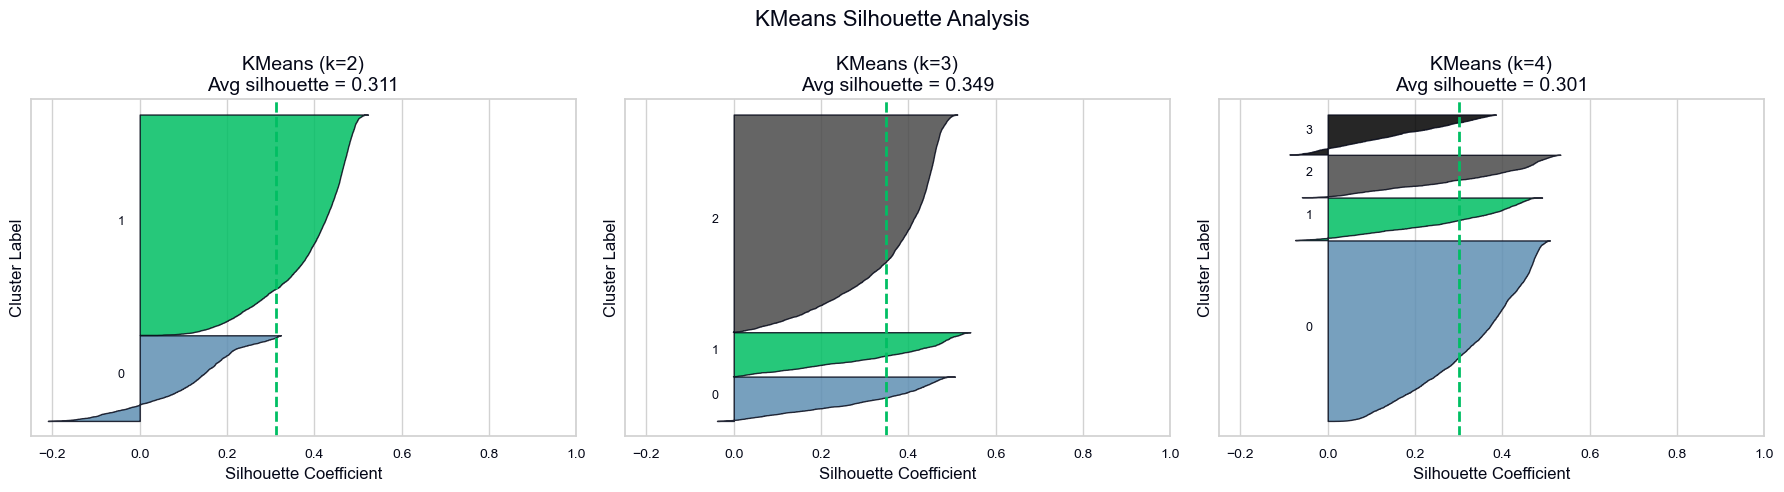

In [39]:
plot_silhouette_grid(X_enhanced_df, "KMeans", [2, 3, 4], "08_kmeans_enhanced_silhouette_k_2_3_4.png")

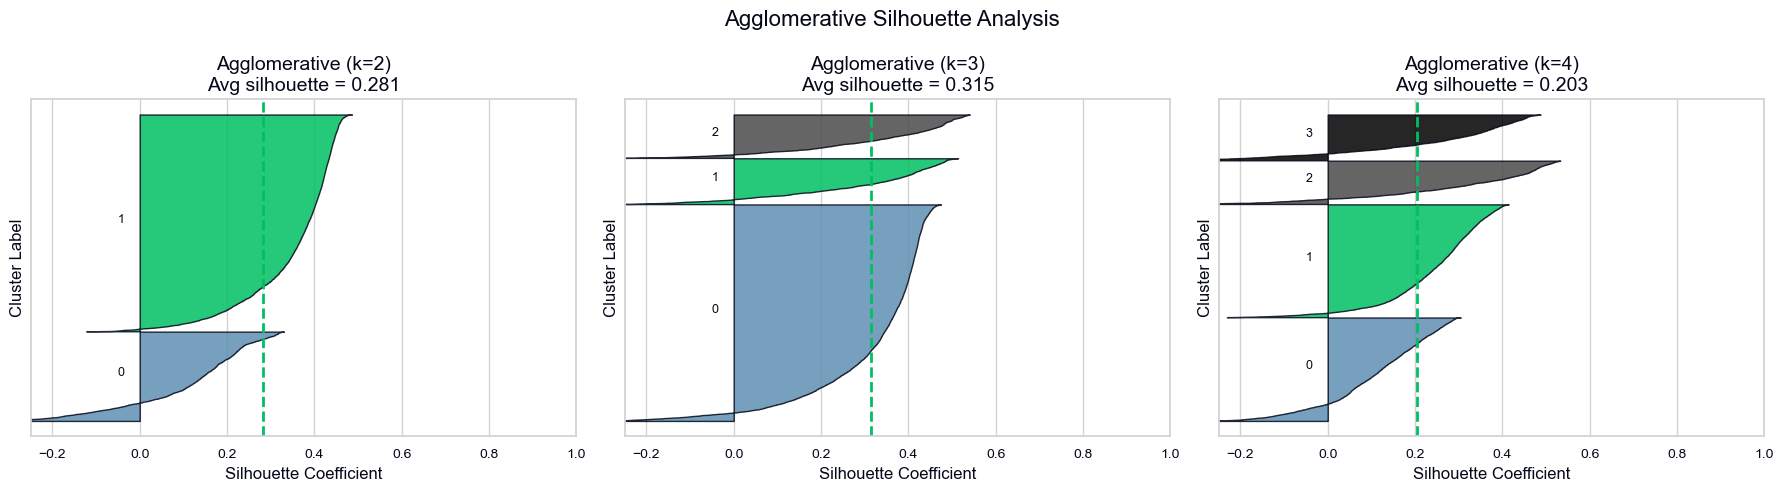

In [41]:
plot_silhouette_grid(X_enhanced_df, "Agglomerative", [2, 3, 4], "09_agglomerative_enhanced_silhouette_k_2_3_4.png")

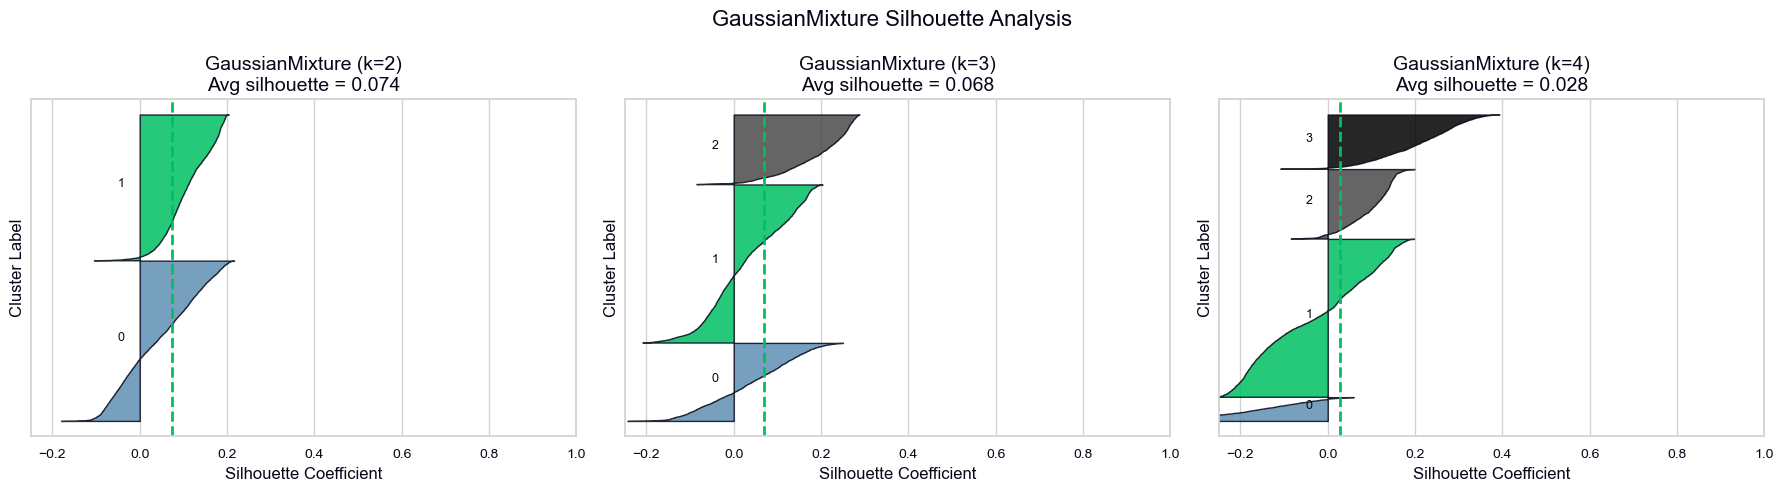

In [42]:
plot_silhouette_grid(X_enhanced_df, "GaussianMixture", [2, 3, 4], "10_gmm_enhanced_silhouette_k_2_3_4.png")

In [43]:
profile_df = df_model.copy()
profile_df["cluster_kmeans_3"] = get_cluster_labels(X_input=X_enhanced_df, model_name="KMeans", n_clusters=3)
profile_df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster_kmeans_3
0,C10001,40.9007,0.8182,95.4000,0.0000,95.4000,0.0000,0.1667,0.0000,0.0833,0.0000,0,2,"1,000.0000",201.8021,139.5098,0.0000,12,2
1,C10002,"3,202.4674",0.9091,0.0000,0.0000,0.0000,"6,442.9455",0.0000,0.0000,0.0000,0.2500,4,0,"7,000.0000","4,103.0326","1,072.3402",0.2222,12,2
2,C10003,"2,495.1489",1.0000,773.1700,773.1700,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0,12,"7,500.0000",622.0667,627.2848,0.0000,12,2
3,C10004,"1,666.6705",0.6364,"1,499.0000","1,499.0000",0.0000,205.7880,0.0833,0.0833,0.0000,0.0833,1,1,"7,500.0000",0.0000,NaN,0.0000,12,1
4,C10005,817.7143,1.0000,16.0000,16.0000,0.0000,0.0000,0.0833,0.0833,0.0000,0.0000,0,1,"1,200.0000",678.3348,244.7912,0.0000,12,2


In [44]:
kmeans3_size_summary = (profile_df["cluster_kmeans_3"].value_counts().sort_index().to_frame(name="customer_count"))
kmeans3_size_summary["customer_pct"] = (kmeans3_size_summary["customer_count"] / len(profile_df)) * 100
kmeans3_size_summary

,customer_count,customer_pct
cluster_kmeans_3,,
0,1299,14.5140
1,1289,14.4022
2,6362,71.0838


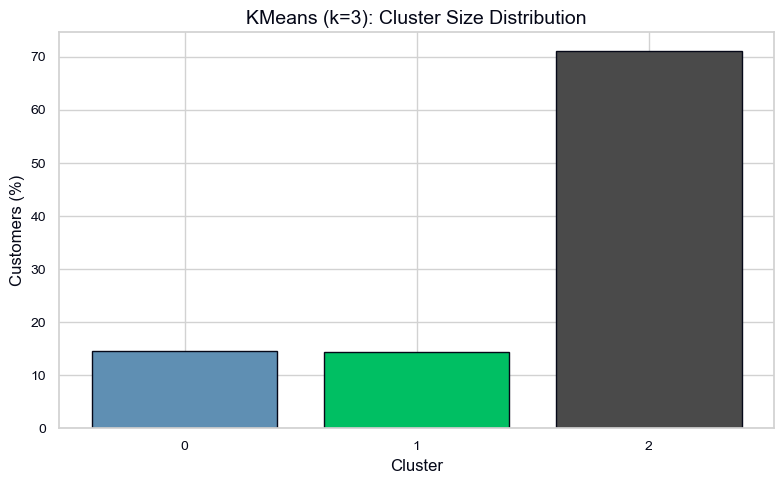

In [45]:
plt.figure(figsize=(8, 5))
plt.bar(
    x=kmeans3_size_summary.index.astype(str),
    height=kmeans3_size_summary["customer_pct"],
    color=[CLUSTER_PALETTE[i] for i in kmeans3_size_summary.index],
    edgecolor=PROJECT_COLORS["deep_navy"])
plt.title("KMeans (k=3): Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Customers (%)")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "11_kmeans_k3_cluster_size_distribution.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [46]:
kmeans3_profile_median = (profile_df.groupby("cluster_kmeans_3")[feature_names].median().T)
kmeans3_profile_median

cluster_kmeans_3,0,1,2
BALANCE,92.0080,27.7166,"1,382.2043"
BALANCE_FREQUENCY,1.0000,0.3636,1.0000
PURCHASES,961.8600,133.0500,343.7450
ONEOFF_PURCHASES,112.0000,0.0000,50.0000
INSTALLMENTS_PURCHASES,470.1200,0.0000,48.3800
CASH_ADVANCE,0.0000,0.0000,232.4979
PURCHASES_FREQUENCY,1.0000,0.1667,0.4167
ONEOFF_PURCHASES_FREQUENCY,0.0833,0.0000,0.0833
PURCHASES_INSTALLMENTS_FREQUENCY,0.7500,0.0000,0.0833
CASH_ADVANCE_FREQUENCY,0.0000,0.0000,0.0833


In [53]:
heatmap_features = [
    "BALANCE",
    "CREDIT_LIMIT",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PURCHASES_FREQUENCY",
    "PRC_FULL_PAYMENT",
    "TENURE"]

kmeans3_heatmap_medians = (profile_df.groupby("cluster_kmeans_3")[heatmap_features].median())
global_medians_k3 = profile_df[heatmap_features].median()
global_stds_k3 = profile_df[heatmap_features].std().replace(0, 1)
kmeans3_heatmap_standardized = ((kmeans3_heatmap_medians - global_medians_k3) / global_stds_k3).T

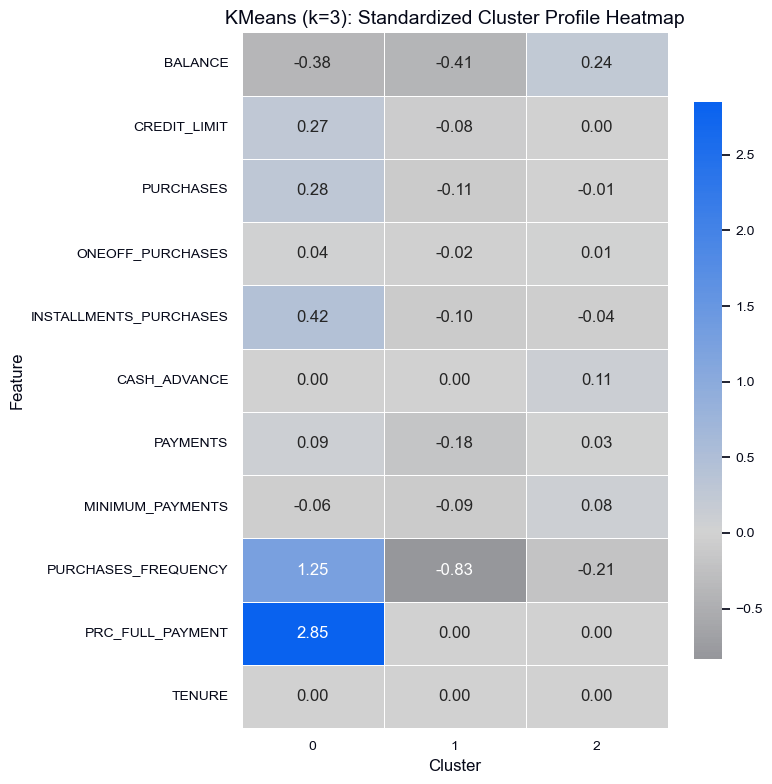

In [49]:

PROFILE_CMAP = LinearSegmentedColormap.from_list(
    "profile_cmap",
    [
        PROJECT_COLORS["deep_navy"],
        PROJECT_COLORS["light_gray"],
        PROJECT_COLORS["bright_blue"]])

plt.figure(figsize=(8, 8))
sns.heatmap(
    kmeans3_heatmap_standardized,
    annot=True,
    fmt=".2f",
    cmap=PROFILE_CMAP,
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8})
plt.title("KMeans (k=3): Standardized Cluster Profile Heatmap")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "12_kmeans_k3_standardized_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [50]:
profile_df_k4 = df_model.copy()
profile_df_k4["cluster_kmeans_4"] = get_cluster_labels(X_enhanced_df, "KMeans", 4)
kmeans4_size_summary = (profile_df_k4["cluster_kmeans_4"].value_counts().sort_index().to_frame(name="customer_count"))
kmeans4_size_summary["customer_pct"] = (kmeans4_size_summary["customer_count"] / len(profile_df_k4)) * 100
kmeans4_size_summary

,customer_count,customer_pct
cluster_kmeans_4,,
0,5290,59.1061
1,1247,13.9330
2,1243,13.8883
3,1170,13.0726


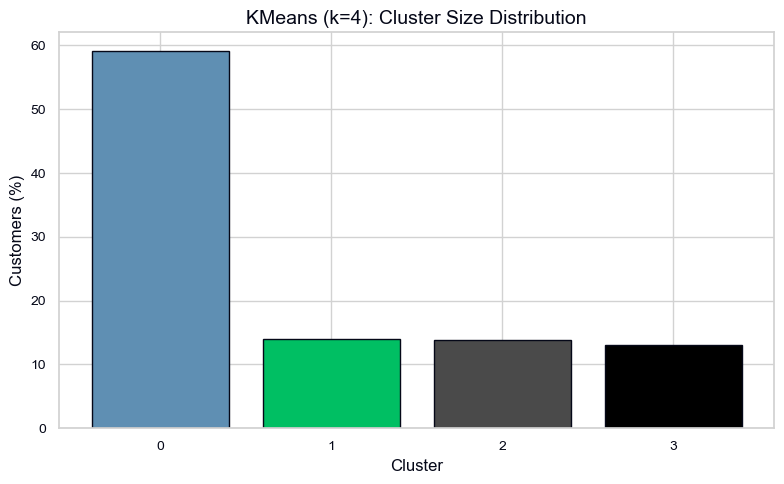

In [51]:
plt.figure(figsize=(8, 5))
plt.bar(
    x=kmeans4_size_summary.index.astype(str),
    height=kmeans4_size_summary["customer_pct"],
    color=[CLUSTER_PALETTE[i] for i in kmeans4_size_summary.index],
    edgecolor=PROJECT_COLORS["deep_navy"])
plt.title("KMeans (k=4): Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Customers (%)")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "13_kmeans_k4_cluster_size_distribution.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [52]:
kmeans4_profile_median = (profile_df_k4.groupby("cluster_kmeans_4")[feature_names].median().T)
kmeans4_profile_median

cluster_kmeans_4,0,1,2,3
BALANCE,"1,163.7026",92.1197,27.7166,"3,032.2317"
BALANCE_FREQUENCY,1.0000,1.0000,0.3636,1.0000
PURCHASES,413.0800,961.8600,133.0000,47.9250
ONEOFF_PURCHASES,75.0000,115.6100,0.0000,0.0000
INSTALLMENTS_PURCHASES,97.3250,460.6000,0.0000,0.0000
CASH_ADVANCE,18.1250,0.0000,0.0000,"3,134.3416"
PURCHASES_FREQUENCY,0.5000,0.9167,0.1667,0.0833
ONEOFF_PURCHASES_FREQUENCY,0.0833,0.0833,0.0000,0.0000
PURCHASES_INSTALLMENTS_FREQUENCY,0.2500,0.7500,0.0000,0.0000
CASH_ADVANCE_FREQUENCY,0.0833,0.0000,0.0000,0.5000


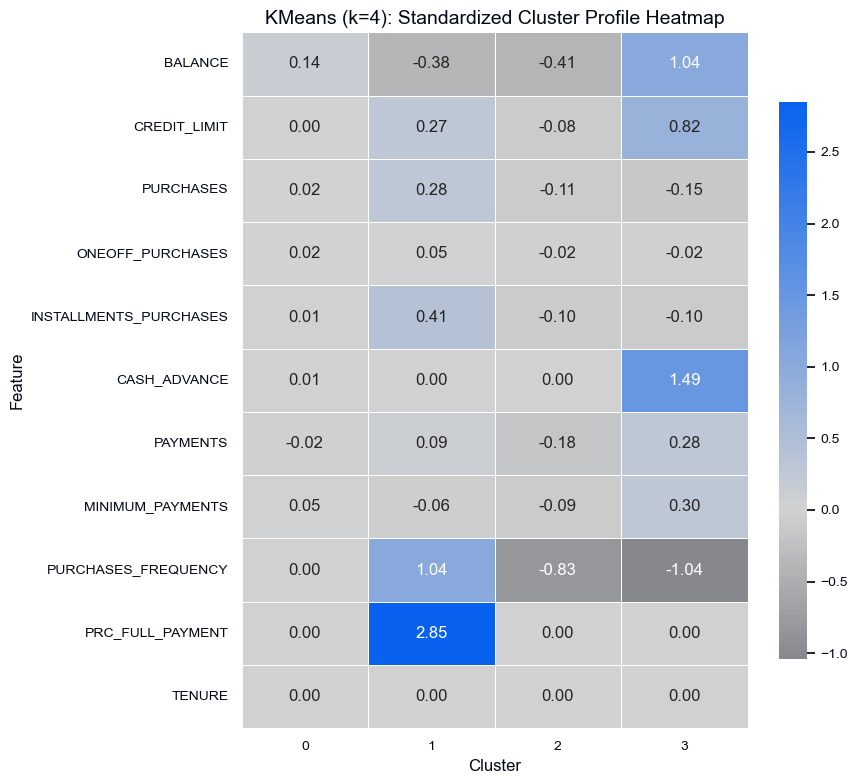

In [54]:
kmeans4_heatmap_medians = (profile_df_k4.groupby("cluster_kmeans_4")[heatmap_features].median())
global_medians_k4 = profile_df_k4[heatmap_features].median()
global_stds_k4 = profile_df_k4[heatmap_features].std().replace(0, 1)
kmeans4_heatmap_standardized = ((kmeans4_heatmap_medians - global_medians_k4) / global_stds_k4).T

plt.figure(figsize=(9, 8))
sns.heatmap(
    kmeans4_heatmap_standardized,
    annot=True,
    fmt=".2f",
    cmap=PROFILE_CMAP,
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8})
plt.title("KMeans (k=4): Standardized Cluster Profile Heatmap")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "14_kmeans_k4_standardized_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [72]:
# 4 clusters are fine, let's put some labels
profile_df_k4["made_purchases"] = (profile_df_k4["PURCHASES"] > 0).astype(int)
profile_df_k4["used_oneoff_purchases"] = (profile_df_k4["ONEOFF_PURCHASES"] > 0).astype(int)
profile_df_k4["used_installments"] = (profile_df_k4["INSTALLMENTS_PURCHASES"] > 0).astype(int)
profile_df_k4["used_cash_advance"] = (profile_df_k4["CASH_ADVANCE"] > 0).astype(int)
profile_df_k4["made_full_payment"] = (profile_df_k4["PRC_FULL_PAYMENT"] > 0).astype(int)
profile_df_k4[[
            "cluster_kmeans_4",
            "made_purchases",
            "used_oneoff_purchases",
            "used_installments",
            "used_cash_advance",
            "made_full_payment"]].sample(10)


,cluster_kmeans_4,made_purchases,used_oneoff_purchases,used_installments,used_cash_advance,made_full_payment
6419,3,1,1,1,1,0
3995,2,1,1,0,0,0
8175,0,1,0,1,0,1
8917,0,0,0,0,1,0
1828,0,1,0,1,0,0
2655,1,1,0,1,0,1
1186,0,1,1,1,1,1
3490,3,1,0,1,1,0
7922,0,1,0,1,1,0
5021,1,1,0,1,0,1


In [73]:
behavior_flag_cols = [
    "made_purchases",
    "used_oneoff_purchases",
    "used_installments",
    "used_cash_advance",
    "made_full_payment"]
kmeans4_behavior_rates = (
    profile_df_k4
    .groupby("cluster_kmeans_4")[behavior_flag_cols]
    .mean()
    .mul(100)
    .T)
kmeans4_behavior_rates

cluster_kmeans_4,0,1,2,3
made_purchases,77.9395,98.6367,76.0257,51.9658
used_oneoff_purchases,55.6144,55.4932,40.8689,43.2479
used_installments,56.9376,86.0465,45.2936,32.9915
used_cash_advance,50.0756,7.6183,32.8238,100.0000
made_full_payment,21.8147,100.0000,31.6975,21.5385


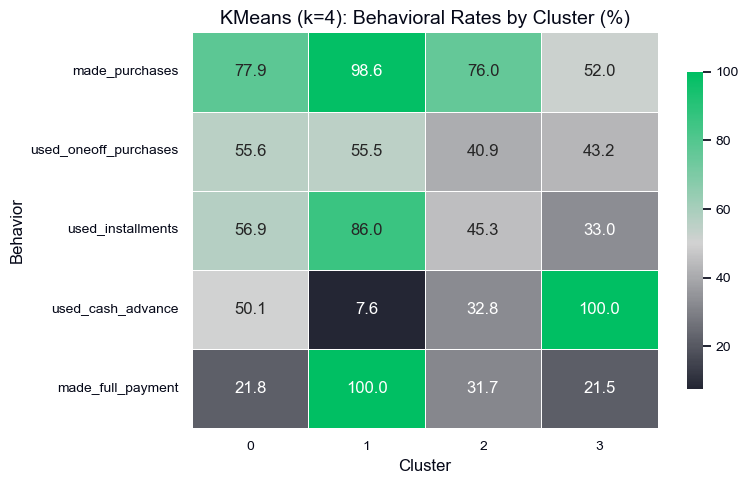

In [75]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    kmeans4_behavior_rates,
    annot=True,
    fmt=".1f",
    cmap=PROFILE_CMAP,
    center=50,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8})
plt.title("KMeans (k=4): Behavioral Rates by Cluster (%)")
plt.xlabel("Cluster")
plt.ylabel("Behavior")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "15_kmeans_k4_behavior_rates_heatmap.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

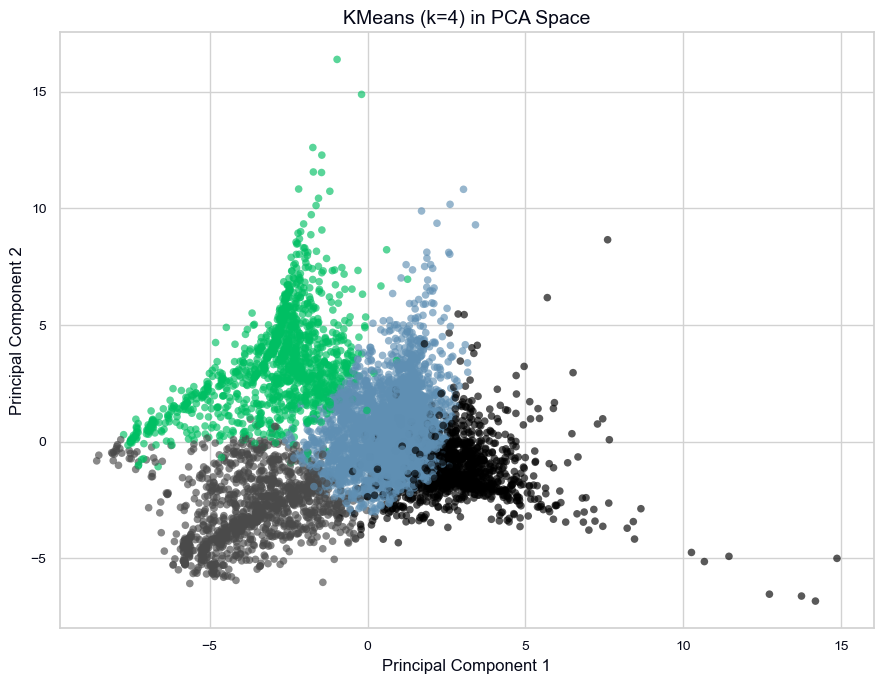

In [76]:
pca_k4 = PCA(n_components=2)
X_k4_pca = pca_k4.fit_transform(X_enhanced_df)
kmeans4_pca_plot_df = pd.DataFrame({
    "PC1": X_k4_pca[:, 0],
    "PC2": X_k4_pca[:, 1],
    "cluster_kmeans_4": profile_df_k4["cluster_kmeans_4"].values})
plt.figure(figsize=(9, 7))
plt.scatter(
    kmeans4_pca_plot_df["PC1"],
    kmeans4_pca_plot_df["PC2"],
    c=[CLUSTER_PALETTE[label] for label in kmeans4_pca_plot_df["cluster_kmeans_4"]],
    alpha=0.65,
    s=30,
    edgecolors="none")
plt.title("KMeans (k=4) in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "16_kmeans_k4_pca_scatter.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [77]:
cluster_name_map_k4 = {
    0: "Mainstream revolving users",
    1: "Active full-payers",
    2: "Low-activity users",
    3: "Cash-advance stressed users"}
profile_df_k4["cluster_kmeans_4_name"] = profile_df_k4["cluster_kmeans_4"].map(cluster_name_map_k4)
profile_df_k4[["cluster_kmeans_4", "cluster_kmeans_4_name"]].drop_duplicates().sort_values("cluster_kmeans_4")


,cluster_kmeans_4,cluster_kmeans_4_name
0,0,Mainstream revolving users
6,1,Active full-payers
3,2,Low-activity users
23,3,Cash-advance stressed users


In [78]:
kmeans4_final_size_summary = (
    profile_df_k4
    .groupby(["cluster_kmeans_4", "cluster_kmeans_4_name"])
    .size()
    .reset_index(name="customer_count")
    .sort_values("cluster_kmeans_4"))
kmeans4_final_size_summary["customer_pct"] = (kmeans4_final_size_summary["customer_count"] / len(profile_df_k4)) * 100
kmeans4_final_size_summary

,cluster_kmeans_4,cluster_kmeans_4_name,customer_count,customer_pct
0,0,Mainstream revolving users,5290,59.1061
1,1,Active full-payers,1247,13.9330
2,2,Low-activity users,1243,13.8883
3,3,Cash-advance stressed users,1170,13.0726


In [88]:
# Final concise cluster summary table for KMeans (k=4)
cluster_order = [0, 1, 2, 3]
size_table = (
    kmeans4_final_size_summary
    .set_index("cluster_kmeans_4")
    .loc[cluster_order, ["cluster_kmeans_4_name", "customer_count", "customer_pct"]])

median_features_for_summary = [
    "BALANCE",
    "CREDIT_LIMIT",
    "PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PURCHASES_FREQUENCY",
    "PRC_FULL_PAYMENT"]

median_table = (
    kmeans4_profile_median
    .loc[median_features_for_summary]
    .T
    .loc[cluster_order])
behavior_table = (
    kmeans4_behavior_rates
    .T
    .loc[cluster_order]
    .rename(columns={
        "made_purchases": "made_purchases_pct",
        "used_oneoff_purchases": "used_oneoff_purchases_pct",
        "used_installments": "used_installments_pct",
        "used_cash_advance": "used_cash_advance_pct",
        "made_full_payment": "made_full_payment_pct"}))

kmeans4_final_summary_table = pd.concat(
    [size_table, median_table, behavior_table],
    axis=1
).reset_index(names="cluster_id")

numeric_cols_summary = kmeans4_final_summary_table.select_dtypes(include=np.number).columns
kmeans4_final_summary_table[numeric_cols_summary] = (
    kmeans4_final_summary_table[numeric_cols_summary].round(2))

kmeans4_final_summary_table = kmeans4_final_summary_table[
    [
        "cluster_id",
        "cluster_kmeans_4_name",
        "customer_count",
        "customer_pct",
        "BALANCE",
        "CREDIT_LIMIT",
        "PURCHASES",
        "INSTALLMENTS_PURCHASES",
        "CASH_ADVANCE",
        "PAYMENTS",
        "MINIMUM_PAYMENTS",
        "PURCHASES_FREQUENCY",
        "PRC_FULL_PAYMENT",
        "made_purchases_pct",
        "used_oneoff_purchases_pct",
        "used_installments_pct",
        "used_cash_advance_pct",
        "made_full_payment_pct"
    ]
]
kmeans4_final_summary_table.T

,0,1,2,3
cluster_id,0,1,2,3
cluster_kmeans_4_name,Mainstream revolving users,Active full-payers,Low-activity users,Cash-advance stressed users
customer_count,5290,1247,1243,1170
customer_pct,59.1100,13.9300,13.8900,13.0700
BALANCE,"1,163.7000",92.1200,27.7200,"3,032.2300"
CREDIT_LIMIT,"3,000.0000","4,000.0000","2,700.0000","6,000.0000"
PURCHASES,413.0800,961.8600,133.0000,47.9200
INSTALLMENTS_PURCHASES,97.3200,460.6000,0.0000,0.0000
CASH_ADVANCE,18.1300,0.0000,0.0000,"3,134.3400"
PAYMENTS,794.7100,"1,111.1500",347.0200,"1,668.2200"


## Modeling Summary

This notebook evaluated multiple clustering approaches for customer segmentation, starting from a baseline preprocessing pipeline and then moving to an enhanced preprocessing pipeline designed to better handle skewed financial variables.

### Modeling workflow

The following clustering models were compared:

- KMeans
- Agglomerative Clustering
- Gaussian Mixture

The initial baseline pipeline used:

- median imputation
- robust scaling

However, the baseline results were not fully satisfactory. Although some solutions showed relatively strong internal metrics, the cluster balance was poor, with one dominant cluster capturing most observations. This suggested that the raw feature geometry was still heavily influenced by skewed monetary variables.

To address this, an enhanced preprocessing pipeline was introduced using:

- median imputation
- selective transformation of highly skewed monetary features with Yeo-Johnson transformation
- robust scaling

This improved the cluster balance and produced more interpretable customer segments.

### Model comparison outcome

After the enhanced preprocessing step:

- **KMeans with 3 clusters** achieved the strongest overall internal metrics.
- **KMeans with 4 clusters** delivered slightly weaker internal metrics, but a more meaningful segmentation structure.
- **Agglomerative Clustering** produced acceptable but generally weaker results than KMeans.
- **Gaussian Mixture** did not provide competitive solutions and was excluded from the final candidate set.

### Why the final solution is KMeans with 4 clusters

Although the 3-cluster KMeans solution performed slightly better on internal validation metrics, the 4-cluster solution was selected as the final candidate because it produced a more useful and interpretable segmentation.

The 3-cluster solution still contained one overly broad majority cluster.  
The 4-cluster solution improved this by separating the large mainstream group into more meaningful behavioral segments without collapsing the overall structure.

### Final cluster interpretation

The final KMeans (k=4) solution can be interpreted as follows:

- **Cluster 0 — Mainstream revolving users**
  - broad majority group
  - moderate balances and payments
  - average purchasing behavior
  - mixed but not extreme financial behavior

- **Cluster 1 — Active full-payers**
  - high purchase activity
  - high installment usage
  - very strong full-payment behavior
  - relatively controlled balances

- **Cluster 2 — Low-activity users**
  - low balances
  - low purchasing activity
  - low transaction frequency
  - limited engagement across most behaviors

- **Cluster 3 — Cash-advance stressed users**
  - very high cash advance usage
  - high balances and credit limits
  - high minimum payments
  - weak purchase activity
  - behavior consistent with more financially pressured revolving usage

### Behavioral validation

The behavioral rate table supported the final interpretation:

- the **Active full-payers** cluster showed the highest rates of purchase activity, installment usage, and full payment
- the **Low-activity users** cluster remained consistently weak across most behavioral indicators
- the **Cash-advance stressed users** cluster showed universal cash-advance activity and the strongest balance pressure profile
- the **Mainstream revolving users** cluster served as the large, moderate baseline segment

### Conclusion

The final KMeans (k=4) solution was selected because it offered the best trade-off between:

- internal clustering quality
- cluster balance
- interpretability
- and business usefulness

This makes it the most appropriate final segmentation for this project.